# Predicting Hotel Cancellations with XGB

Predicting cancellations can help a hotel optimize room occupancy and revenue. When rooms are released for sale to other guests, the hotel can avoid overbooking, which can lead to lost revenue and a poor guest experience. Furthermore, predicting cancellations can inform staffing and inventory management, allowing the hotel to make a more efficient use of its resources. A model that accurately predicts cancellations can help a hotel increase revenue and work more efficiently.

In this notebook, we will visualize the reservations dataset to search for insights, and use an Extreme Gradient Boosting Classifier to predict cancellations. 

# Importing Libraries & Loading Files

We need to import a few libraries and get the files we will be working with to begin working with the data.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt #Data visualization
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns #Data visualization
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler #Data scaling
import xgboost as xgb #Extreme Gradient Boosting
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, auc #Metrics

      
# Creating DataFrame (use data/ when running locally; see README)
_data_path = 'data/Hotel Reservations.csv'
import os
if not os.path.exists(_data_path):
    _data_path = '/kaggle/input/hotel-reservations-classification-dataset/Hotel Reservations.csv'
reservations = pd.read_csv(_data_path, parse_dates=['arrival_date'])

#Renaming Columns
#This seemed easier than labeling all charts later
reservations = reservations.rename({'no_of_adults':'No. of Adults',
                                    'no_of_children':'No. of Children',
                                    'no_of_weekend_nights':'No. of Weekend Nights',
                                    'no_of_week_nights':'No. of Week Nights',
                                    'type_of_meal_plan':'Type of Meal Plan' ,
                                    'required_car_parking_space':'Required Parking' ,
                                    'room_type_reserved':'Room Type' ,
                                    'lead_time':'Lead Time' ,
                                    'arrival_year':'Year',
                                    'arrival_month':'Month' ,
                                    'arrival_date':'Date',
                                    'market_segment_type':'Market Segment' ,
                                    'repeated_guest':'Repeated Guest',
                                    'no_of_previous_cancellations':'No. of Previous Cancellations' ,
                                    'no_of_previous_bookings_not_canceled':'No. of Successful Bookings' ,
                                    'avg_price_per_room':'Mean Room Price',
                                    'no_of_special_requests':'No. of Special Requests' ,
                                    'booking_status':'Canceled' }, axis=1)

#Creating Categories
categories = ['Type of Meal Plan',
             'Room Type', 
             'Market Segment',
             'Canceled']

#Renaming Categories for Readability
reservations[categories] = reservations[categories].astype('category')
reservations['Canceled'] = reservations['Canceled'].replace({'Not_Canceled':False, 'Canceled':True})
reservations['Room Type'] = reservations['Room Type'].replace({'Room_Type 1':'Type 1',
                                                                                 'Room_Type 2':'Type 2',
                                                                                 'Room_Type 3':'Type 3',
                                                                                 'Room_Type 4':'Type 4',
                                                                                 'Room_Type 5':'Type 5',
                                                                                 'Room_Type 6':'Type 6',
                                                                                 'Room_Type 7':'Type 7'})

#Describing Data
#This will help check for missing values or outliers
round(reservations.describe(include='all'))

,Booking_ID,No. of Adults,No. of Children,No. of Weekend Nights,No. of Week Nights,Type of Meal Plan,Required Parking,Room Type,Lead Time,Year,Month,Date,Market Segment,Repeated Guest,No. of Previous Cancellations,No. of Successful Bookings,Mean Room Price,No. of Special Requests,Canceled
count,36275,36275.0,36275.0,36275.0,36275.0,36275,36275.0,36275,36275.0,36275.0,36275.0,36275,36275,36275.0,36275.0,36275.0,36275.0,36275.0,36275
unique,36275,NaN,NaN,NaN,NaN,4,NaN,7,NaN,NaN,NaN,31,5,NaN,NaN,NaN,NaN,NaN,2
top,INN00001,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Type 1,NaN,NaN,NaN,13,Online,NaN,NaN,NaN,NaN,NaN,False
freq,1,NaN,NaN,NaN,NaN,27835,NaN,28130,NaN,NaN,NaN,1358,23214,NaN,NaN,NaN,NaN,NaN,24390
mean,NaN,2.0,0.0,1.0,2.0,NaN,0.0,NaN,85.0,2018.0,7.0,NaN,NaN,0.0,0.0,0.0,103.0,1.0,NaN
std,NaN,1.0,0.0,1.0,1.0,NaN,0.0,NaN,86.0,0.0,3.0,NaN,NaN,0.0,0.0,2.0,35.0,1.0,NaN
min,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,2017.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN
25%,NaN,2.0,0.0,0.0,1.0,NaN,0.0,NaN,17.0,2018.0,5.0,NaN,NaN,0.0,0.0,0.0,80.0,0.0,NaN
50%,NaN,2.0,0.0,1.0,2.0,NaN,0.0,NaN,57.0,2018.0,8.0,NaN,NaN,0.0,0.0,0.0,99.0,0.0,NaN
75%,NaN,2.0,0.0,2.0,3.0,NaN,0.0,NaN,126.0,2018.0,10.0,NaN,NaN,0.0,0.0,0.0,120.0,1.0,NaN


# Exploratory Data Analysis

With the describe method, we can see detailed information about each of the columns of the DataFrame, including the number of values for each column, the minimum, maximum, and median values for numerical variables, and the mode for categorical variables. This helps us identify outliers and determine if there are any unusual values (such as a negative number where the values should be positive).

It seems that there are no missing values, but before we proceed with the model preparation, let's make a few visualizations and check for outliers.
 
 
 

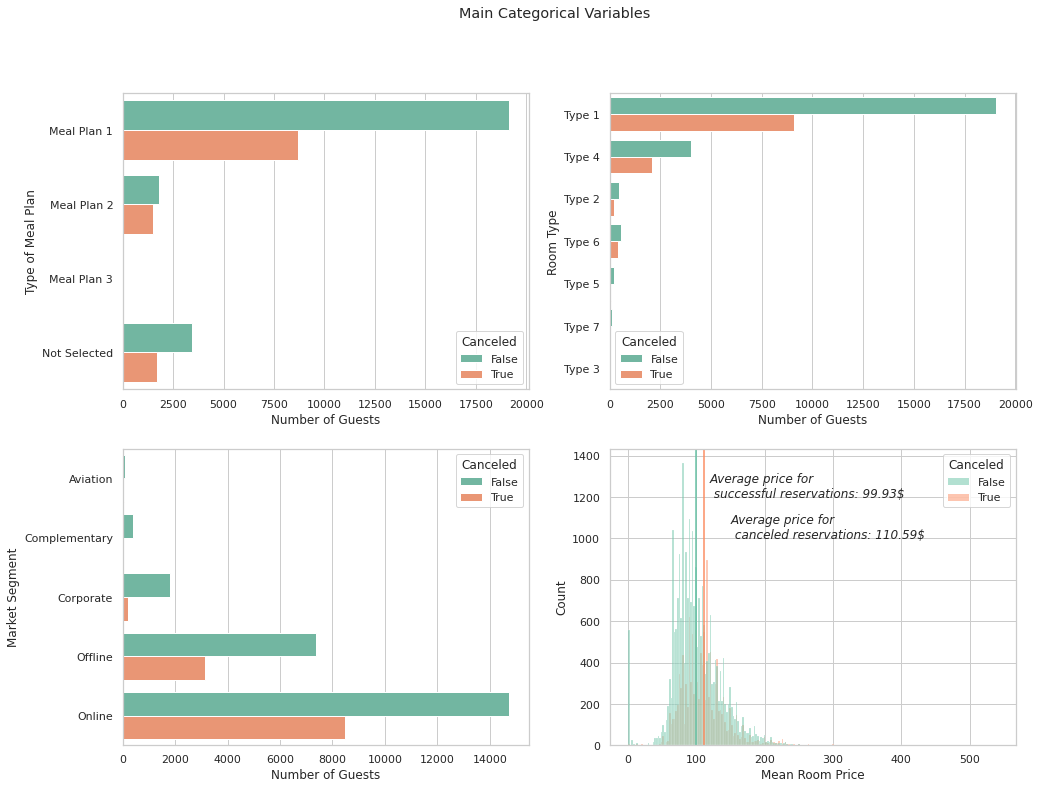

In [2]:
sns.set_context('notebook')
sns.set_style('whitegrid')
sns.set_palette('Set2')

palette = sns.color_palette('Set2')

dual_colors = ['#66c2a5', '#ffffff', '#ffffff', '#fc8d62']

mean_price_canceled = reservations[reservations['Canceled'] == True]['Mean Room Price'].mean()
mean_price_not_canceled = reservations[reservations['Canceled'] == False]['Mean Room Price'].mean()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16,12))

fig.suptitle('Main Categorical Variables')

cat_dict = {'Type of Meal Plan':ax1,
             'Room Type':ax2, 
             'Market Segment':ax3}

for key, value in cat_dict.items():
    sns.countplot(data=reservations, y=key, hue='Canceled', ax=value)
    value.set_xlabel('Number of Guests')
    value.set_ylabel(f'{key}')

sns.histplot(data=reservations, x='Mean Room Price', hue='Canceled', ax=ax4)
ax4.axvline(x=mean_price_canceled, 
            color=palette[1])
ax4.axvline(x=mean_price_not_canceled, 
            color=palette[0])
ax4.annotate(f'Average price for \n canceled reservations: {mean_price_canceled:.2f}$', 
             xy=(150, 1000),
            font='roboto',
            fontstyle='italic')
ax4.annotate(f'Average price for \n successful reservations: {mean_price_not_canceled:.2f}$', 
             xy=(120, 1200),
            font='roboto',
            fontstyle='italic')

plt.show()

We can notice that:

 * Overall, charts show a steady proportion of canceled bookings;
 * The type 6 rooms have a higher proportion of cancellations;
 * Compared proportionally to online cancellations, offline and corporate cancellations are less likely to happen.
 * When compared to successful bookings, cancellations show a higher average price, 110.59$.

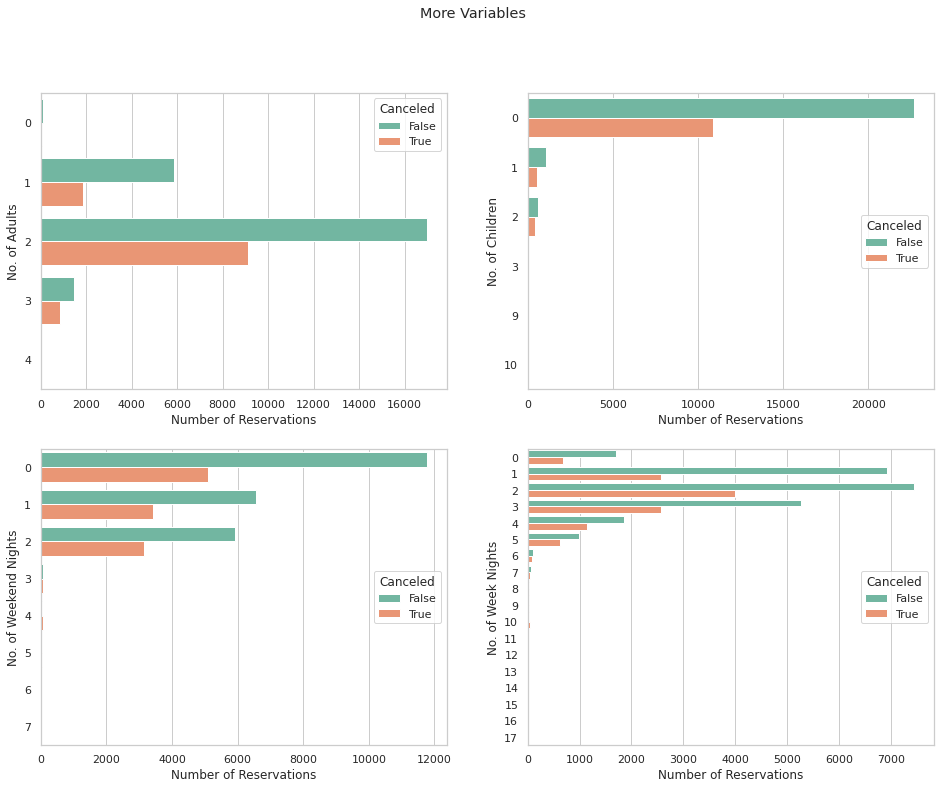

In [3]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16,12))

fig.suptitle('More Variables')

nos_dict = {'No. of Adults':ax1,
            'No. of Children':ax2, 
            'No. of Weekend Nights':ax3,
            'No. of Week Nights':ax4}

for key, value in nos_dict.items():
    sns.countplot(data=reservations, y=key, hue='Canceled', ax=value)
    value.set_xlabel('Number of Reservations')
    value.set_ylabel(f'{key}')

plt.show()

Here are a few additional insights.

* For 3 adults, the proportion of canceled reservations is higher;

* In addition, the proportion of canceled reservations is higher for two children;

* It appears that the likelihood of cancellation increases with the increase in weeknights.

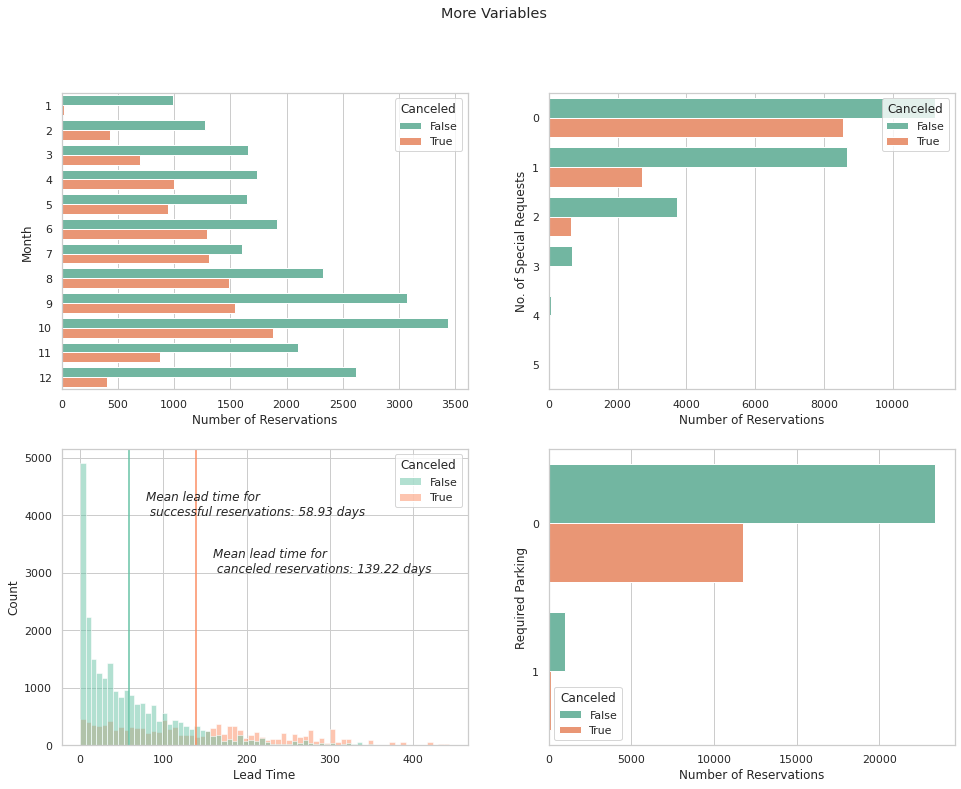

In [4]:
mean_lt_canceled = reservations[reservations['Canceled'] == True]['Lead Time'].mean()
mean_lt_not_canceled = reservations[reservations['Canceled'] == False]['Lead Time'].mean()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16,12))

fig.suptitle('More Variables')

nos_dict = {'Month':ax1,
            'No. of Special Requests':ax2,
            'Required Parking':ax4}

for key, value in nos_dict.items():
    sns.countplot(data=reservations, y=key, hue='Canceled', ax=value)
    value.set_xlabel('Number of Reservations')
    value.set_ylabel(f'{key}')
    
sns.histplot(data=reservations,x='Lead Time', hue='Canceled', ax=ax3)
ax3.axvline(x=mean_lt_canceled, 
            color=palette[1])
ax3.axvline(x=mean_lt_not_canceled, 
            color=palette[0])
ax3.annotate(f'Mean lead time for \n canceled reservations: {mean_lt_canceled:.2f} days', 
             xy=(mean_lt_canceled+20, 3000),
            font='roboto',
            fontstyle='italic')
ax3.annotate(f'Mean lead time for \n successful reservations: {mean_lt_not_canceled:.2f} days', 
             xy=(mean_lt_not_canceled+20, 4000),
            font='roboto',
            fontstyle='italic')

plt.show()

The last four charts revealed some interesting insights that can help us better understand the patterns of cancellations. Here are some key takeaways:

* Winter appears to decrease the proportion of cancellations, suggesting that seasonal factors may play a role in cancellations.

* As the number of special requests increases, the proportion of cancellations seems to decrease. This could be due to customers being more invested in their reservations and less likely to cancel if they have special requests.

* Reservations with a longer lead time are more likely to be canceled. This could be due to customers changing their plans or finding better deals closer to the date of their reservation.

* Interestingly, reservations with required parking show almost no issues with cancellations. This could be due to customers being more committed to their plans if they have to secure parking in advance.

# Preprocessing & Creating the XGB

To build an effective classification model, we need to follow some key steps. 

* First, we'll transform our categorical data using one-hot encoding. This technique creates binary variables for each category, helping our model better understand the relationships between different categories.

* We'll need to rescale our data. This step is crucial for improving our model's accuracy, as it helps ensure that all features are on a similar scale.

* To get a more accurate sense of how our model is performing, we'll be using StratifiedKFold instead of the traditional train/test split. This technique allows us to train and evaluate our model on multiple subsets of the data, giving us a better sense of its overall performance.

By following these steps, we'll be able to build a robust and reliable classification model that can handle even the most complex datasets. Let's dive in!

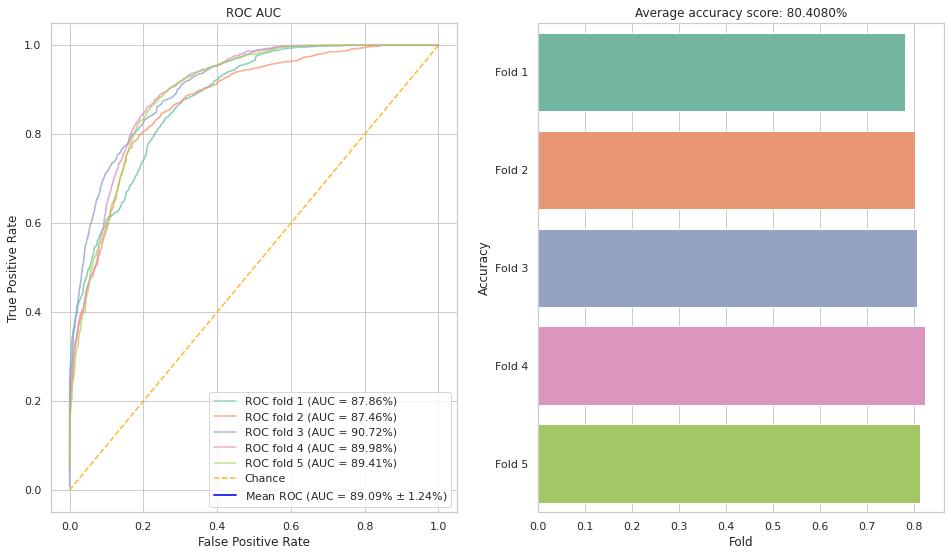

In [5]:
reservations = reservations.drop('Booking_ID', axis=1)
reservations = pd.get_dummies(reservations)

# Split dataset into dependent and independent variable
X = reservations.copy()
y = X.pop('Canceled').values  # Store the target variable as a numpy array

# Initiate MinMaxScaler
mms = MinMaxScaler()

# Create a StratifiedKFold object with 5 folds
skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Create empty lists to store the accuracy scores and AUC values
scores = []
aucs = []

# Create an empty array to store feature importances for each fold
feature_importances = np.zeros((X.shape[1], skf.n_splits))

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

# Iterate over the folds and train/test the XGBoost model on each one
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]  # Use .iloc to index the DataFrame by position
    y_train, y_test = y[train_index], y[test_index]
    
    X_train = mms.fit_transform(X_train)
    X_test= mms.fit_transform(X_test)
    
    # Create an XGBoost model and fit it to the training data
    xgb_model = xgb.XGBClassifier()
    xgb_model.fit(X_train, y_train)
       
    # Make predictions on the test data and calculate the accuracy and AUC
    y_pred = xgb_model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
    roc_auc = auc(fpr, tpr)
    scores.append(score)
    aucs.append(roc_auc)
    
    # Collect the feature importances for this fold
    feature_importances[:, i] = xgb_model.feature_importances_

    # Plot the ROC AUC curve for the current fold
    sns.lineplot(x=fpr, 
                 y=tpr, 
                 alpha=0.7, 
                 label=f'ROC fold {i+1} (AUC = {roc_auc:0.2%})', 
                 ax=ax1)

# Plot the ROC AUC curve for all folds
sns.lineplot(x=[0, 1], 
             y=[0, 1], 
             linestyle='--', 
             color='orange', 
             label='Chance', 
             alpha=.8, 
             ax=ax1)

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

ax1.plot(np.mean(fpr), 
         np.mean(tpr), 
         color='b',
         label=f'Mean ROC (AUC = {mean_auc:0.2%} $\pm$ {std_auc:0.2%})',
         lw=2, 
         alpha=.8)

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC AUC')
ax1.legend(loc="lower right")

# Create a barplot of the accuracy scores

sns.barplot(y=[f"Fold {i+1}" for i in range(len(scores))], x=scores, ax=ax2, palette='Set2')
ax2.set_xlabel('Fold')
ax2.set_ylabel('Accuracy')
ax2.set_title(f"Average accuracy score: {np.mean(scores):.4%}")

# Show the plots
plt.show()

# Results & Model Importances

The charts show that the models present a good ROC AUC and the folds appear to have a high accuracy score. 

Now let's examine the model's feature importances. This allows us to see which features the model considers the most influential in cancellations.

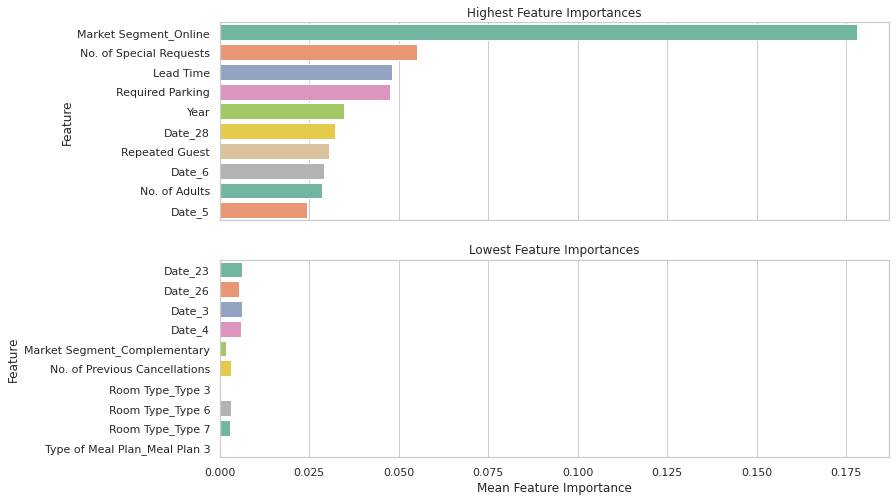

In [6]:
sns.set_style('whitegrid')

# Compute the mean and standard deviation of each feature importance across all folds
mean_importances = np.mean(feature_importances, axis=1)
std_importances = np.std(feature_importances, axis=1)

# Create a pandas DataFrame of the mean and standard deviation importances
importances_df = pd.DataFrame({'feature': X.columns, 'importance': mean_importances, 'std': std_importances})

# Sort the DataFrame by mean importance
importances_df = importances_df.sort_values('importance', ascending=False)

# Plot the feature importances as a bar plot
fig, (ax1, ax2 )= plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.barplot(data=importances_df.head(n=10), x='importance', y='feature', palette='Set2', ax=ax1)
ax1.set_xlabel('')
ax1.set_ylabel('Feature')
ax1.set_title('Highest Feature Importances')

sns.barplot(data=importances_df.tail(n=10).sort_values('feature'), x='importance', y='feature', palette='Set2', ax=ax2)
ax2.set_xlabel('Mean Feature Importance')
ax2.set_ylabel('Feature')
ax2.set_title('Lowest Feature Importances')

plt.show()


# Model Features & Conclusion

Our model confirmed a few of our previous insights:

* Online Market Segment seems to gain the highest weight, but that might be because it's also the most common segment;

* Furthermore, a particular number of special requests might also affect cancellations, which is further identified by the model;

* Similarly, the time before the reservation has shown a large influence, though the model seems to have placed less importance on them;

* Required parking also shows some of the highest influence, as seen previously in our visualizations.
